In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('./src/data_science_job.csv')
df

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19153,7386,city_173,0.878,Male,No relevent experience,no_enrollment,Graduate,Humanities,14.0,NaN,NaN,42.0,1.0
19154,31398,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,14.0,NaN,NaN,52.0,1.0
19155,24576,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,50-99,Pvt Ltd,44.0,0.0
19156,5756,city_65,0.802,Male,Has relevent experience,no_enrollment,High School,NaN,0.0,500-999,Pvt Ltd,97.0,0.0


In [4]:
df.isnull().sum()

enrollee_id                  0
city                         0
city_development_index     479
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
training_hours             766
target                       0
dtype: int64

In [5]:
df.isnull().mean() * 100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [7]:
cols = [var  for var in df.columns if df[var].isnull().mean() <0.05 and df[var].isnull().mean() > 0]
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [8]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
8465,0.924,Full time course,Masters,9.0,45.0
2221,0.624,NaN,Graduate,14.0,78.0
14082,0.910,no_enrollment,Graduate,5.0,54.0
7171,0.890,no_enrollment,NaN,2.0,33.0
8607,0.555,no_enrollment,Graduate,4.0,33.0


In [9]:
len(df[cols].dropna())/len(df)

0.8968577095730244

In [10]:
new_df = df[cols].dropna()
df.shape, new_df.shape

((19158, 13), (17182, 5))

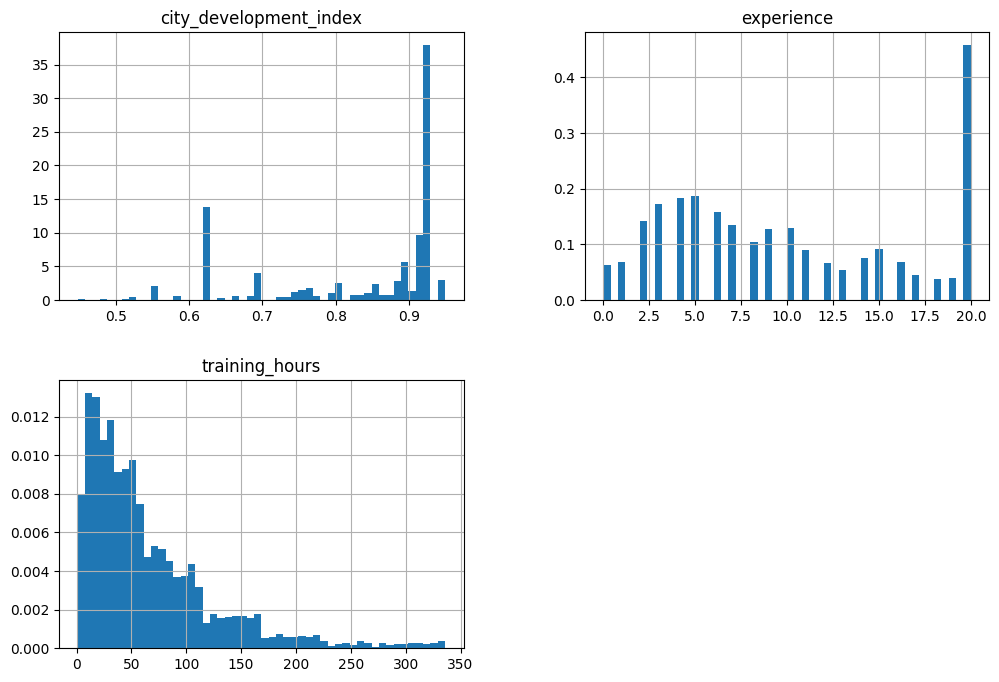

In [11]:
new_df.hist(bins=50,density=True, figsize=(12,8))
plt.show()

<Axes: >

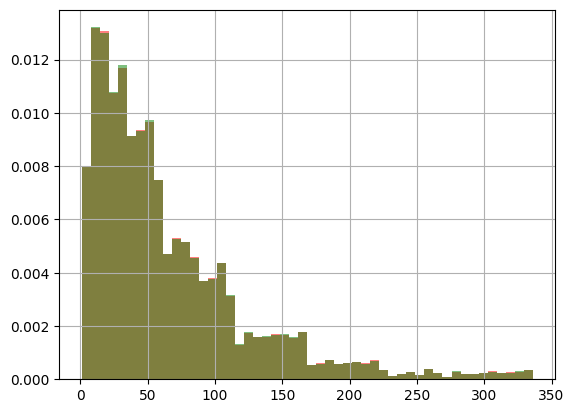

In [13]:
fig = plt.figure()
ax = fig.add_subplot(111)

#original data
df['training_hours'].hist(bins=50, density=True, alpha=0.5, ax=ax, label='Original data',color = 'red')
#after dropping missing values
new_df['training_hours'].hist(bins=50, density=True, alpha=0.5, ax=ax, label='After dropping missing values',color = 'green')


<Axes: ylabel='Density'>

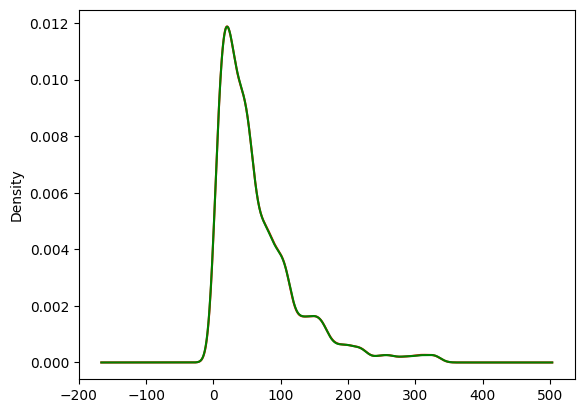

In [15]:
# with pdf
fig = plt.figure()
ax = fig.add_subplot(111)

#original data
df['training_hours'].plot.density(ax=ax, label='Original data',color = 'red')
#after dropping missing values
new_df['training_hours'].plot.density(ax=ax, label='After dropping missing values',color = 'green')

In [18]:
# same for other two numerical columns

In [22]:
# for categorical columns, we can compare the value counts before and after dropping missing values
df['education_level'].value_counts()

education_level
Graduate          11598
Masters            4361
High School        2017
Phd                 414
Primary School      308
Name: count, dtype: int64

In [23]:
df['enrolled_university'].value_counts()

enrolled_university
no_enrollment       13817
Full time course     3757
Part time course     1198
Name: count, dtype: int64

In [28]:
temp = pd.concat([df['education_level'].value_counts()/len(df)
                  , new_df['education_level'].value_counts()/len(new_df)], axis=1)
temp.columns = ['Original', 'After CCA']
temp

,Original,After CCA
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587


In [27]:
# same for enrolled_university
temp = pd.concat([df['enrolled_university'].value_counts()/len(df)
                    , new_df['enrolled_university'].value_counts()/len(new_df)], axis=1)
temp.columns = ['Original', 'After CCA']
temp


,Original,After CCA
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079
